# STATS 507, Week 8 practice: scikit learn

### Problem 1 Your first machine learning project
This practice shows how scikit-learn can be used to recognize images of hand-written digits, from 0-9.

Load data: https://scikit-learn.org/1.5/modules/generated/sklearn.datasets.load_digits.html

Split data: https://scikit-learn.org/1.5/modules/generated/sklearn.model_selection.train_test_split.html

Create a SVM model: https://scikit-learn.org/dev/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

Evaluate the model performance:https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.classification_report.html



In [1]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt 

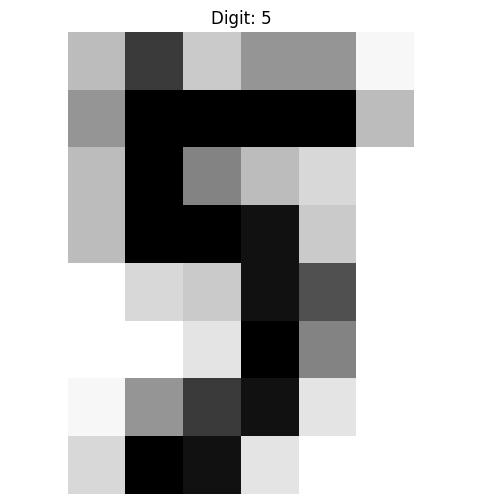

In [15]:
# Load the dataset
digits = datasets.load_digits()
#print(digits.DESCR)
#print(data)
#print(digits.data)

#X = digits.data
#y = digits.target

X, y = datasets.load_digits(return_X_y=True)

# Visualize a sample digit
plt.figure(figsize=(6, 6))
plt.imshow(X[33].reshape(8, 8), cmap="Greys") # The input x
plt.title(f"Digit: {y[33]}")                  # The output label y
plt.axis('off')
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
# Split the data into training (80%) and testing sets (20%) 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)
print(y_train.shape, y_test.shape)

(1437,) (360,)


In [20]:
from sklearn import svm
# Create a SVM classifier with rbf kernal and Regularization parameter = 1
clf = svm.SVC(kernel = 'rbf', C = 1.0)

In [22]:
# "Train/fit the model on the training data"
clf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
# Evaluate the model
from sklearn.metrics import classification_report

# "Evaluate the model on the test data"
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



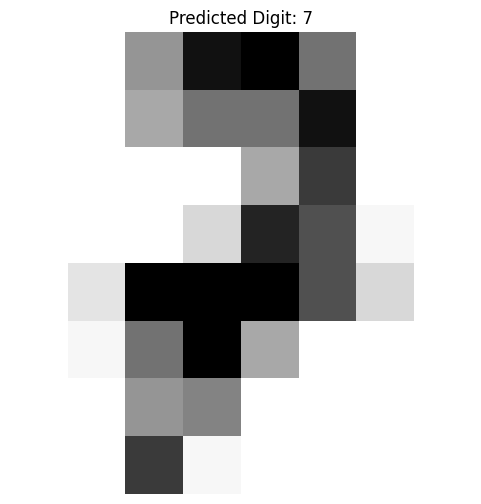

In [26]:
# Visualize the predicted digit
sample_digit = X_test[23]
prediction = clf.predict([sample_digit])
plt.figure(figsize=(6, 6))
plt.imshow(sample_digit.reshape(8, 8), cmap="Greys")
plt.title(f"Predicted Digit: {prediction[0]}")
plt.axis('off')
plt.show()